# BK14 PCCP Broken-Wire Signal Comparison by Generation Method

This notebook uses the functions in `src/bk_analysis` to compute time-domain, spectral, and cumulative-energy results for `corrosion` and `cut` broken-wire signals. Plotting is intentionally kept inside the notebook so that figure layout and styles can be modified freely.


In [17]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# %matplotlib inline
%matplotlib qt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Times New Roman'     # 普通文本
mpl.rcParams['mathtext.fontset'] = 'custom'         # 数学文本用自定义字体
mpl.rcParams['mathtext.rm'] = 'Times New Roman'     # 正常(math roman)
mpl.rcParams['mathtext.it'] = 'Times New Roman:italic'
mpl.rcParams['mathtext.bf'] = 'Times New Roman:bold'

plt.rcParams["font.family"] = "Times New Roman, SimSun" # 显示汉字
plt.rcParams["font.size"] = 16 # 字号
%matplotlib qt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from bk_analysis import run_generation_method_analysis


In [18]:
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'bk14_generation_method_analysis'
PTP_HIGHPASS_CUTOFF_HZ = 1_000.0
# Fixed PSD window length after arrival (seconds), configurable in notebook.
PSD_SEGMENT_DURATION_S = 0.02
TIME_FEATURE_BANDS_KHZ = (
    (1, 100),    (1, 5),    (5, 10),  
    (10,20),    (20, 30),    (30, 40),
    (40,50),    (10, 50),  (50, 100)
)
TIME_FEATURE_BANDS_HZ = tuple((int(low * 1000), int(high * 1000)) for low, high in TIME_FEATURE_BANDS_KHZ)

result = run_generation_method_analysis(
    DATA_DIR,
    output_dir=OUTPUT_DIR,
    time_feature_bands_hz=TIME_FEATURE_BANDS_HZ,
    ptp_highpass_cutoff_hz=PTP_HIGHPASS_CUTOFF_HZ,
    psd_segment_duration_s=PSD_SEGMENT_DURATION_S,
)
OUTPUT_DIR

WindowsPath('E:/codes/ZZ-BK/outputs/bk14_generation_method_analysis')

## Sample Index

Check the number of samples, sampling rates, and arrival-time source.


In [21]:
result.record_index.groupby(['method', 'arrival_source']).size().rename('count').reset_index()


,method,arrival_source,count
0,corrosion,labeled,12
1,cut,labeled,12


## Time-Domain Feature Tables


In [ ]:
result.time_features.head()

In [ ]:
result.method_summary

## Spectral Summary Objects

Each summary contains plain arrays: `x`, `median`, `p10`, `p90`, and `mean`.


In [22]:
result.psd_summaries['corrosion'].as_dict()

{'x': array([     0.        ,    250.62656642,    501.25313283,    751.87969925,
          1002.50626566,   1253.13283208,   1503.7593985 ,   1754.38596491,
          2005.01253133,   2255.63909774,   2506.26566416,   2756.89223058,
          3007.51879699,   3258.14536341,   3508.77192982,   3759.39849624,
          4010.02506266,   4260.65162907,   4511.27819549,   4761.9047619 ,
          5012.53132832,   5263.15789474,   5513.78446115,   5764.41102757,
          6015.03759398,   6265.6641604 ,   6516.29072682,   6766.91729323,
          7017.54385965,   7268.17042607,   7518.79699248,   7769.4235589 ,
          8020.05012531,   8270.67669173,   8521.30325815,   8771.92982456,
          9022.55639098,   9273.18295739,   9523.80952381,   9774.43609023,
         10025.06265664,  10275.68922306,  10526.31578947,  10776.94235589,
         11027.56892231,  11278.19548872,  11528.82205514,  11779.44862155,
         12030.07518797,  12280.70175439,  12531.3283208 ,  12781.95488722,
       

## Plot: Time-Domain Features

Each feature is drawn on its own subplot so you can adjust labels, size, scales, and style directly here.


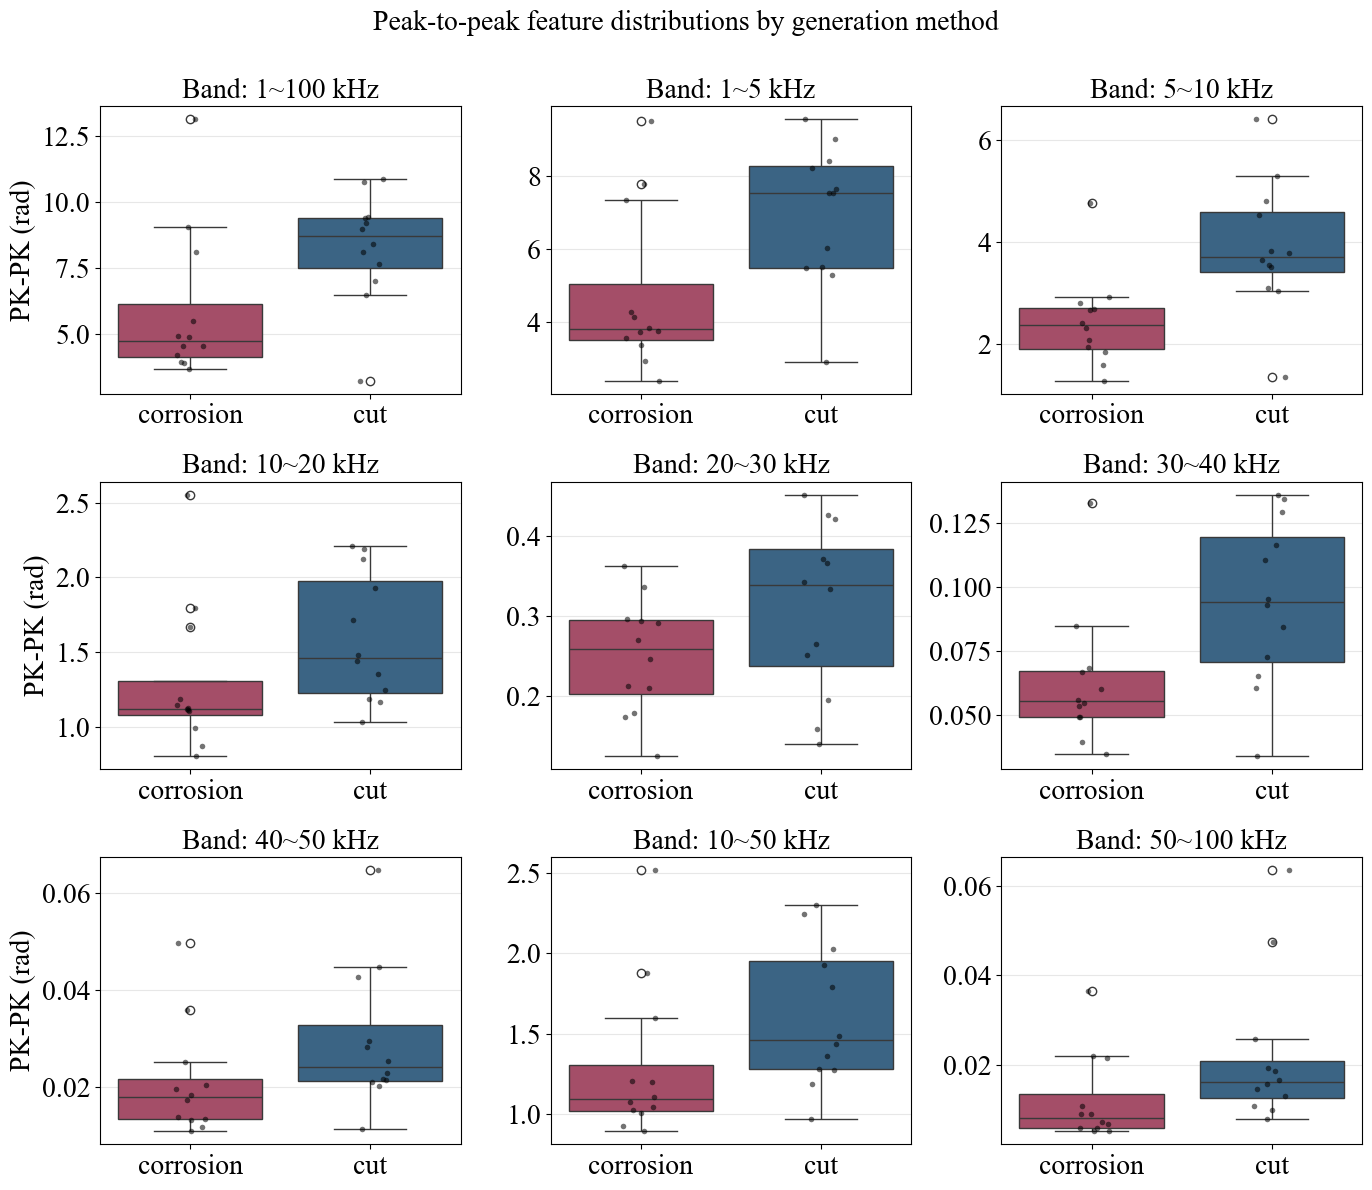

In [26]:
label_fontsize = 20
tick_fontsize = 20
palette = {'corrosion': '#b33f62', 'cut': '#2f6690'}

# ---------------------------------------- Duration: standalone figure ----------------------------------------
fig_duration, ax_duration = plt.subplots(figsize=(8, 6))
plot_df_duration = result.time_features[['method', 'duration_s']].rename(columns={'duration_s': 'value'})
sns.boxplot(data=plot_df_duration, x='method', y='value', hue='method', dodge=False, palette=palette, ax=ax_duration)
if ax_duration.legend_ is not None:
    ax_duration.legend_.remove()
sns.stripplot(data=plot_df_duration, x='method', y='value', color='black', alpha=0.55, size=4, ax=ax_duration)
ax_duration.set_title('Duration (s)', fontsize=label_fontsize)
ax_duration.set_xlabel('', fontsize=label_fontsize)
ax_duration.set_ylabel('Duration (s)', fontsize=label_fontsize)
ax_duration.tick_params(axis='both', labelsize=tick_fontsize)
ax_duration.grid(True, alpha=0.3, axis='y')
fig_duration.tight_layout()

# Energy in first 0.01 s: standalone figure
fig_energy, ax_energy = plt.subplots(figsize=(12, 12))
plot_df_energy = result.time_features[['method', 'start_energy_0p01s']].rename(columns={'start_energy_0p01s': 'value'})
sns.boxplot(data=plot_df_energy, x='method', y='value', hue='method', dodge=False, palette=palette, ax=ax_energy)
if ax_energy.legend_ is not None:
    ax_energy.legend_.remove()
sns.stripplot(data=plot_df_energy, x='method', y='value', color='black', alpha=0.55, size=4, ax=ax_energy)
ax_energy.set_title('Energy in first 0.01 s', fontsize=label_fontsize)
ax_energy.set_xlabel('', fontsize=label_fontsize)
ax_energy.set_ylabel('Start Energy (0.01 s)', fontsize=label_fontsize)
ax_energy.tick_params(axis='both', labelsize=tick_fontsize)
ax_energy.grid(True, alpha=0.3, axis='y')
fig_energy.tight_layout()

# Peak-to-peak bands: 3 columns and multiple rows
ptp_feature_specs = [
    (
        f'ptp_band_{low_hz}_{high_hz}_hz',
        f'Band: {low_khz}~{high_khz} kHz',
    )
    for (low_khz, high_khz), (low_hz, high_hz) in zip(TIME_FEATURE_BANDS_KHZ, TIME_FEATURE_BANDS_HZ)
]

n_features = len(ptp_feature_specs)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))
fig_ptp, axes = plt.subplots(n_rows, n_cols, figsize=(14, 12))
axes = np.atleast_1d(axes).ravel()

for idx, (ax, (column, title)) in enumerate(zip(axes, ptp_feature_specs)):
    plot_df = result.time_features[['method', column]].rename(columns={column: 'value'})
    sns.boxplot(data=plot_df, x='method', y='value', hue='method', dodge=False, palette=palette, ax=ax)
    if ax.legend_ is not None:
        ax.legend_.remove()
    sns.stripplot(data=plot_df, x='method', y='value', color='black', alpha=0.55, size=4, ax=ax)
    ax.set_title(title, fontsize=label_fontsize)
    ax.set_xlabel('', fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.grid(True, alpha=0.3, axis='y')

    # Only keep y-axis label on the left-most subplot of each row,
    # while each subplot keeps its own y-ticks and y-scale.
    if idx % n_cols == 0:
        ax.set_ylabel('PK-PK (rad)', fontsize=label_fontsize)
    else:
        ax.set_ylabel('')

for ax in axes[n_features:]:
    ax.remove()

fig_ptp.suptitle('Peak-to-peak feature distributions by generation method', y=0.995, fontsize=label_fontsize)
fig_ptp.tight_layout()
fig_ptp.subplots_adjust(wspace=0.25)

fig_duration
fig_energy
fig_ptp

## 绘制包络线
### 所有包络线

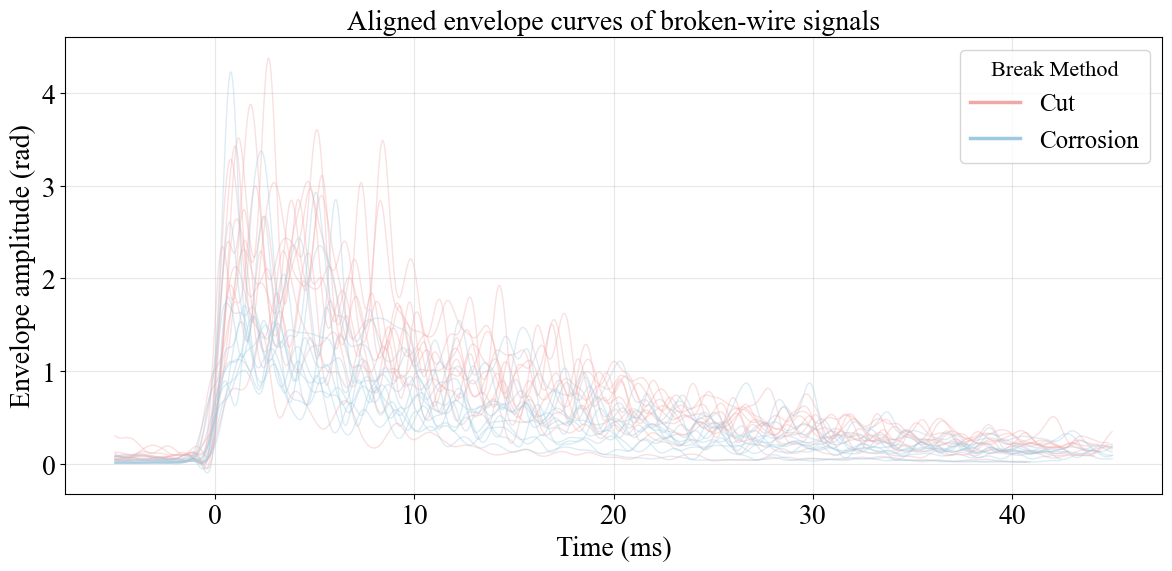

In [25]:
from scipy import signal
from matplotlib.lines import Line2D

from bk_analysis.io import load_generation_method_records

records = load_generation_method_records(DATA_DIR)

# Configurable high-pass cutoff for envelope preprocessing (Hz).
ENVELOPE_HIGHPASS_CUTOFF_HZ = 1_000.0
# Configurable low-pass cutoff for envelope smoothing (Hz).
ENVELOPE_SMOOTH_CUTOFF_HZ = 800.0

# Aligned display window around arrival (ms)
time_min_ms = -5.0
time_max_ms = 45.0

# Group envelope curves by method after alignment at arrival time.
envelope_groups = {'cut': [], 'corrosion': []}
for record in records:
    nyquist = 0.5 * record.sample_rate
    cutoff_hz = min(ENVELOPE_HIGHPASS_CUTOFF_HZ, nyquist * 0.999)

    # High-pass first, then compute analytic-signal envelope.
    sos = signal.butter(4, cutoff_hz / nyquist, btype='highpass', output='sos')
    signal_highpassed = signal.sosfiltfilt(sos, record.signal)
    envelope_raw = np.abs(signal.hilbert(signal_highpassed))

    # Smooth envelope with low-pass filtering to suppress rapid oscillations.
    smooth_cutoff_hz = min(ENVELOPE_SMOOTH_CUTOFF_HZ, nyquist * 0.3)
    sos_env = signal.butter(4, smooth_cutoff_hz / nyquist, btype='lowpass', output='sos')
    envelope = signal.sosfiltfilt(sos_env, envelope_raw)

    arrival_idx = record.arrival_index
    time_ms = (np.arange(len(envelope)) - arrival_idx) / record.sample_rate * 1000.0

    mask = (time_ms >= time_min_ms) & (time_ms <= time_max_ms)
    envelope_groups[record.method].append((time_ms[mask], envelope[mask]))

fig_envelope, ax = plt.subplots(figsize=(12, 6))
line_colors = {'cut': '#f2a7a7', 'corrosion': '#9ecae1'}

for method in ['cut', 'corrosion']:
    for time_ms, envelope in envelope_groups[method]:
        ax.plot(time_ms, envelope, color=line_colors[method], linewidth=1.0, alpha=0.35)

legend_handles = [
    Line2D([0], [0], color=line_colors['cut'], lw=2.5, label='Cut'),
    Line2D([0], [0], color=line_colors['corrosion'], lw=2.5, label='Corrosion'),
]

ax.set_title('Aligned envelope curves of broken-wire signals', fontsize=label_fontsize)
ax.set_xlabel('Time (ms)', fontsize=label_fontsize)
ax.set_ylabel('Envelope amplitude (rad)', fontsize=label_fontsize)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.legend(handles=legend_handles, title='Break Method', fontsize=label_fontsize-2)
fig_envelope.tight_layout()
fig_envelope

### 平均包络线

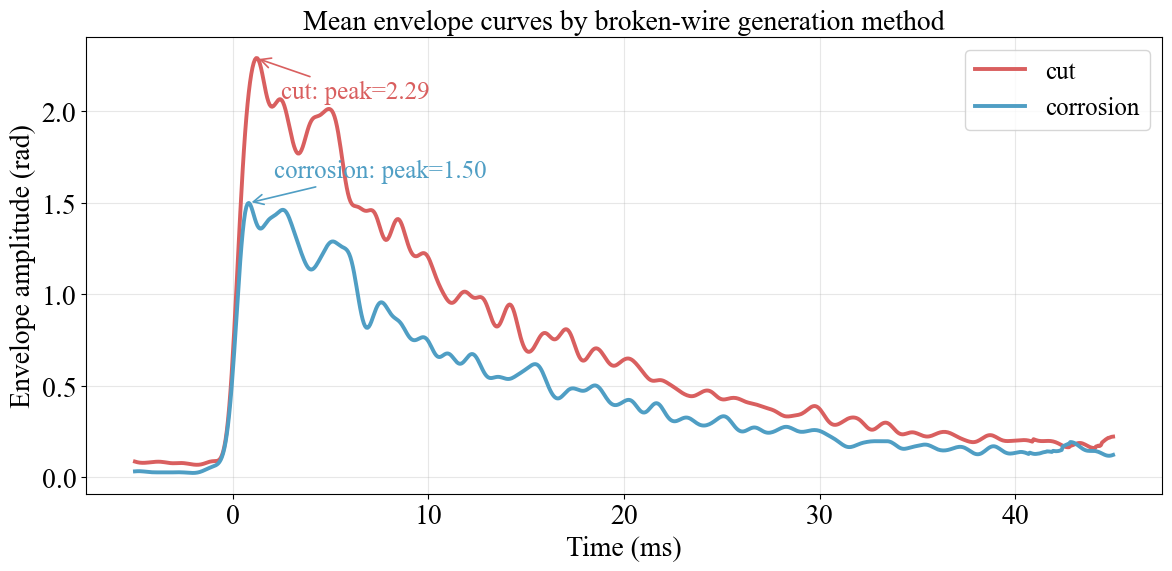

In [32]:
# Average envelope curves by method and plot only two representative lines.
time_grid_ms = np.linspace(time_min_ms, time_max_ms, 800)

method_order = ['cut', 'corrosion']
mean_envelopes = {}
for method in method_order:
    curves = envelope_groups.get(method, [])
    if not curves:
        continue

    interpolated_curves = []
    for curve_time_ms, curve_env in curves:
        interp_env = np.interp(time_grid_ms, curve_time_ms, curve_env, left=np.nan, right=np.nan)
        interpolated_curves.append(interp_env)

    stacked = np.vstack(interpolated_curves)
    mean_envelopes[method] = np.nanmean(stacked, axis=0)

fig_envelope_mean, ax = plt.subplots(figsize=(12, 6))
mean_line_colors = {'cut': '#d95f5f', 'corrosion': '#4f9ec4'}
peak_points = {}

for method in method_order:
    if method not in mean_envelopes:
        continue

    mean_curve = mean_envelopes[method]
    ax.plot(time_grid_ms, mean_curve, color=mean_line_colors[method], linewidth=2.8, label=f'{method}')# mean envelope')

    peak_idx = int(np.nanargmax(mean_curve))
    peak_points[method] = (time_grid_ms[peak_idx], mean_curve[peak_idx])

# Auto-adjust annotation position by peak location to avoid crossing plot border.
x_min, x_max = np.nanmin(time_grid_ms), np.nanmax(time_grid_ms)
all_mean_values = np.concatenate([mean_envelopes[m] for m in method_order if m in mean_envelopes])
y_min, y_max = np.nanmin(all_mean_values), np.nanmax(all_mean_values)
x_span = max(x_max - x_min, 1e-9)
y_span = max(y_max - y_min, 1e-9)

for method in method_order:
    if method not in peak_points:
        continue

    peak_x, peak_y = peak_points[method]
    x_ratio = (peak_x - x_min) / x_span
    y_ratio = (peak_y - y_min) / y_span

    dx = -50 if x_ratio > 0.80 else 18
    dy = -16 if y_ratio > 0.82 else 14
    ha = 'right' if dx < 0 else 'left'
    va = 'top' if dy < 0 else 'bottom'

    ax.annotate(
        f"{method}: peak={peak_y:.2f}",
        xy=(peak_x, peak_y),
        xytext=(dx, dy),
        textcoords='offset points',
        ha=ha,
        va=va,
        fontsize=label_fontsize - 2,
        color=mean_line_colors[method],
        arrowprops=dict(arrowstyle='->', color=mean_line_colors[method], lw=1.2),
        annotation_clip=True,
    )

ax.set_title('Mean envelope curves by broken-wire generation method', fontsize=label_fontsize)
ax.set_xlabel('Time (ms)', fontsize=label_fontsize)
ax.set_ylabel('Envelope amplitude (rad)', fontsize=label_fontsize)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', labelsize=tick_fontsize)
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(fontsize=label_fontsize - 2)
fig_envelope_mean.tight_layout()
fig_envelope_mean

### 一个信号的包络线（对比不同包络光滑参数）

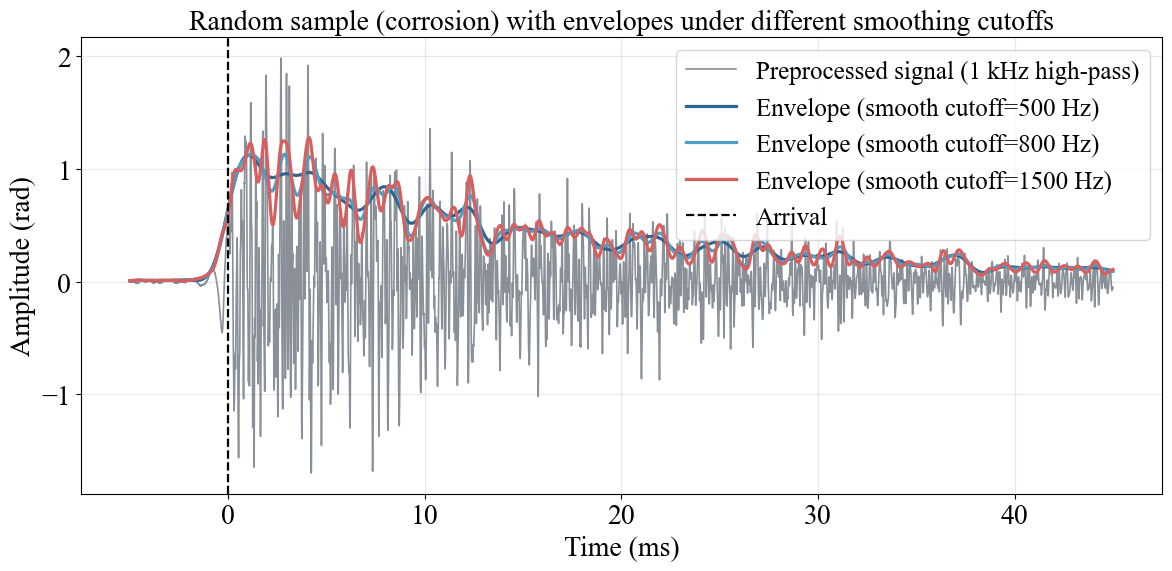

In [35]:
# Randomly pick one broken-wire signal and compare envelopes under different smoothing cutoffs.
rng = np.random.default_rng()
random_record = records[int(rng.integers(0, len(records)))]

nyquist = 0.5 * random_record.sample_rate
cutoff_hz = min(ENVELOPE_HIGHPASS_CUTOFF_HZ, nyquist * 0.999)

# Shared preprocessing: high-pass and analytic envelope.
sos = signal.butter(4, cutoff_hz / nyquist, btype='highpass', output='sos')
signal_highpassed = signal.sosfiltfilt(sos, random_record.signal)
envelope_raw = np.abs(signal.hilbert(signal_highpassed))

arrival_idx = random_record.arrival_index
time_ms = (np.arange(len(envelope_raw)) - arrival_idx) / random_record.sample_rate * 1000.0
mask = (time_ms >= time_min_ms) & (time_ms <= time_max_ms)

# Compare different envelope smoothing cutoffs (Hz).
smooth_cutoff_candidates_hz = [500.0, 800.0, 1500.0]
envelopes_by_cutoff = {}
for smooth_cutoff in smooth_cutoff_candidates_hz:
    smooth_cutoff_hz = min(smooth_cutoff, nyquist * 0.3)
    sos_env = signal.butter(4, smooth_cutoff_hz / nyquist, btype='lowpass', output='sos')
    envelopes_by_cutoff[smooth_cutoff] = signal.sosfiltfilt(sos_env, envelope_raw)

fig_single_envelope, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    time_ms[mask],
    signal_highpassed[mask],
    color='#6c757d',
    linewidth=1.2,
    alpha=0.8,
    label='Preprocessed signal (1 kHz high-pass)',
)

cutoff_colors = {500.0: '#2f6690', 800.0: '#4f9ec4', 1500.0: '#d95f5f'}
for smooth_cutoff in smooth_cutoff_candidates_hz:
    envelope = envelopes_by_cutoff[smooth_cutoff]
    ax.plot(
        time_ms[mask],
        envelope[mask],
        color=cutoff_colors[smooth_cutoff],
        linewidth=2.3,
        label=f'Envelope (smooth cutoff={int(smooth_cutoff)} Hz)',
    )

ax.axvline(0.0, color='black', linestyle='--', linewidth=1.6, label='Arrival')

ax.set_title(
    f"Random sample ({random_record.method}) with envelopes under different smoothing cutoffs",
    fontsize=label_fontsize,
)
ax.set_xlabel('Time (ms)', fontsize=label_fontsize)
ax.set_ylabel('Amplitude (rad)', fontsize=label_fontsize)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=label_fontsize - 2)
ax.tick_params(axis='both', labelsize=tick_fontsize)
fig_single_envelope.tight_layout()
fig_single_envelope

## Plot: Probability PSD

在单元格 20 里，图例中的 10%-90% 指的是每个频率点上的分位区间，不是整条曲线只取 10% 到 90% 的片段。

具体理解：

1. 对某一个固定频率 f（比如 5 kHz），会收集该方法下所有样本在这个频率上的 PSD 值。
2. 把这些 PSD 值从小到大排序：
   1. 第 10 百分位（p10）：有 10% 的样本比它更小。
   2. 第 90 百分位（p90）：有 10% 的样本比它更大。
3. 图中的阴影带就是从 p10 到 p90，这表示该频率下“中间 80% 样本”的波动范围。
4. 线条中的 median 是中位数曲线（第 50 百分位）。

所以：
1. 阴影越宽，说明该频率处样本离散性越大。
2. 阴影越窄，说明该频率处样本一致性越好。
3. 超出阴影的极端高低值仍然存在，只是没有画在这个 10%-90% 区间里。

结合你现在的分段统计规则再补一句：
1. 100 kHz 以下，这个区间来自 200 kHz 和 500 kHz 两类样本共同统计【各12个样本】。
2. 100 kHz 以上，这个区间只来自 500 kHz 样本统计【各9个样本】。

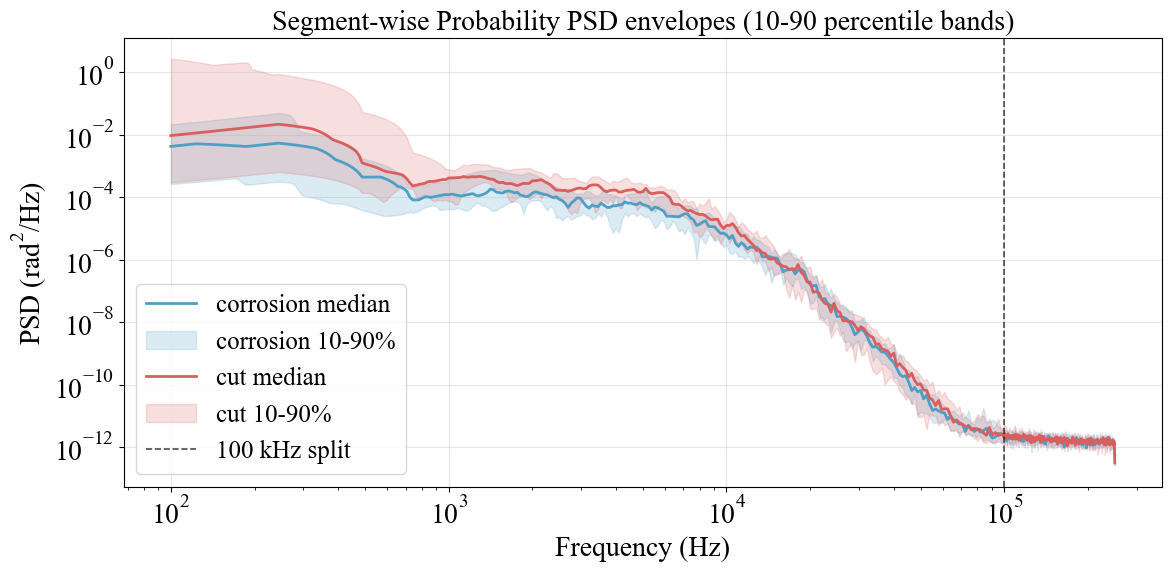

In [40]:
# Segment-wise PSD statistics for mixed sampling rates:
# <=100 kHz: use both 200 kHz and 500 kHz samples; >100 kHz: use only 500 kHz samples.
split_frequency_hz = 100_000.0

spectral_df = result.spectral_records.merge(
    result.record_index[['path', 'sample_rate_hz']],
    on='path',
    how='left',
)

# Fallback: infer sample rate from PSD frequency axis if merge misses any rows.
missing_sr = spectral_df['sample_rate_hz'].isna()
if missing_sr.any():
    spectral_df.loc[missing_sr, 'sample_rate_hz'] = [
        2.0 * float(np.max(freq)) for freq in spectral_df.loc[missing_sr, 'frequency_hz']
    ]

max_frequency_hz = float(max(np.max(freq) for freq in spectral_df['frequency_hz']))
low_grid = np.geomspace(100.0, split_frequency_hz, 280)
if max_frequency_hz > split_frequency_hz:
    high_grid = np.geomspace(split_frequency_hz, max_frequency_hz, 180)
    frequency_grid = np.unique(np.concatenate([low_grid, high_grid]))
else:
    frequency_grid = low_grid
low_mask = frequency_grid <= split_frequency_hz

fig_psd_probability, ax = plt.subplots(figsize=(12, 6))
palette = {'cut': '#d95f5f', 'corrosion': '#4f9ec4'}    #{'corrosion': '#b33f62', 'cut': '#2f6690'} 

for method, group in spectral_df.groupby('method'):
    selected_curves = []
    n_low = 0
    n_high = 0

    for _, row in group.iterrows():
        freq = row['frequency_hz']
        psd = row['psd']
        sample_rate_hz = float(row['sample_rate_hz'])
        interp_psd = np.interp(frequency_grid, freq, psd, left=np.nan, right=np.nan)

        segmented_curve = np.full_like(frequency_grid, np.nan, dtype=float)
        segmented_curve[low_mask] = interp_psd[low_mask]
        n_low += 1

        # Only 500 kHz samples contribute to >100 kHz frequency statistics.
        if sample_rate_hz >= 400_000.0:
            segmented_curve[~low_mask] = interp_psd[~low_mask]
            n_high += 1

        selected_curves.append(segmented_curve)

    stacked = np.vstack(selected_curves)
    median = np.nanmedian(stacked, axis=0)
    p10 = np.nanpercentile(stacked, 10, axis=0)
    p90 = np.nanpercentile(stacked, 90, axis=0)

    ax.plot(frequency_grid, median, label=f'{method} median', color=palette[method], linewidth=2)
    ax.fill_between(frequency_grid, p10, p90, color=palette[method], alpha=0.20, label=f'{method} 10-90%')

    # Sample-count annotation for segment-wise statistics.
    text_y = np.nanmedian(median)
    # ax.text(
    #     1_500.0,
    #     text_y,
    #     f"{method}: n<=100k={n_low}, n>100k={n_high}",
    #     color=palette[method],
    #     fontsize=11,
    #     alpha=0.9,
    # )

ax.axvline(split_frequency_hz, color='black', linestyle='--', linewidth=1.2, alpha=0.7, label='100 kHz split')
ax.set_title('Segment-wise Probability PSD envelopes (10-90 percentile bands)', fontsize=label_fontsize)
ax.set_xlabel('Frequency (Hz)', fontsize=label_fontsize)
ax.set_ylabel(r'PSD (rad$^2$/Hz)', fontsize=label_fontsize)
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.legend(fontsize = label_fontsize - 2)
fig_psd_probability.tight_layout()
fig_psd_probability


## Plot: Cumulative PSD Energy Ratio
主结论

两类信号的累计能量曲线非常接近，说明在“1 kHz 以上”频段内，整体能量分布形态相似。

cut（蓝）在一部分频段上略早抬升，表示其能量在较低频率处累积得稍快一点；但差异不大。

频率-能量关系（近似读图）

在几 kHz 范围内，累计比值快速从接近 0 上升到约 0.5，说明主要能量集中在低到中频。

到约 (6\sim 8) kHz 时，两类都接近 0.9。

到约 10 kHz 左右基本接近 1，说明 1 kHz 以上的有效能量几乎都已累计完成，高频尾部贡献较小。

阴影带（10%-90%）含义与稳定性

两类阴影带大面积重叠，表示样本间波动存在且两类差异并不强分离。

在中低频段阴影较宽，说明该段个体差异更明显；到高频端收敛后离散度减小。

对判别任务的启示

仅靠这条累计能量曲线，区分 cut 与 corrosion 的能力有限。

更适合把它作为辅助特征，和单元格 12 的分频带 PK-PK 特征联合使用。

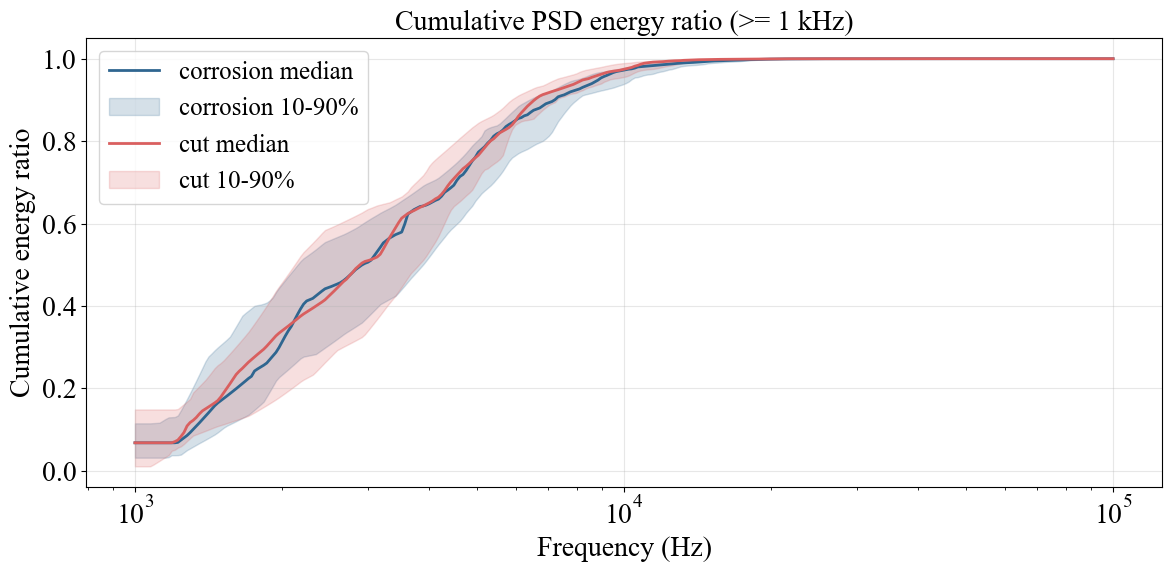

In [45]:
# Cumulative PSD energy ratio from 1 kHz upward only.
energy_start_hz = 1_000.0

spectral_df = result.spectral_records
max_common_hz = min(float(np.max(freq)) for freq in spectral_df['frequency_hz'])
frequency_grid = np.geomspace(energy_start_hz, max_common_hz, 320)

fig_cumulative_energy, ax = plt.subplots(figsize=(12, 6))
palette = {'corrosion':'#2f6690', 'cut': '#d95f5f'}

for method, group in spectral_df.groupby('method'):
    energy_curves = []

    for _, row in group.iterrows():
        freq = row['frequency_hz']
        psd = row['psd']

        valid = freq >= energy_start_hz
        if np.count_nonzero(valid) < 2:
            continue

        freq_valid = freq[valid]
        psd_valid = psd[valid]

        cumulative_energy = np.cumsum(psd_valid)
        if cumulative_energy[-1] <= 0:
            continue

        cumulative_ratio = cumulative_energy / cumulative_energy[-1]
        curve_interp = np.interp(frequency_grid, freq_valid, cumulative_ratio)
        energy_curves.append(curve_interp)

    if not energy_curves:
        continue

    stacked = np.vstack(energy_curves)
    median = np.median(stacked, axis=0)
    p10 = np.percentile(stacked, 10, axis=0)
    p90 = np.percentile(stacked, 90, axis=0)

    ax.plot(frequency_grid, median, label=f'{method} median', color=palette[method], linewidth=2)
    ax.fill_between(frequency_grid, p10, p90, color=palette[method], alpha=0.20, label=f'{method} 10-90%')

ax.set_title('Cumulative PSD energy ratio (>= 1 kHz)', fontsize=label_fontsize)
ax.set_xlabel('Frequency (Hz)', fontsize=label_fontsize)
ax.set_ylabel('Cumulative energy ratio', fontsize=label_fontsize)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.legend(fontsize=label_fontsize - 2)
fig_cumulative_energy.tight_layout()
fig_cumulative_energy


## Additional Quantitative Indicators


In [16]:
rows = []
for method, summary in result.energy_summaries.items():
    for level in [0.5, 0.8, 0.9, 0.95]:
        idx = int(np.argmax(summary.median >= level))
        rows.append({
            'method': method,
            'energy_ratio': level,
            'frequency_hz': float(summary.x[idx]),
        })
pd.DataFrame(rows)


,method,energy_ratio,frequency_hz
0,corrosion,0.50,250.626566
1,corrosion,0.80,501.253133
2,corrosion,0.90,2756.892231
3,corrosion,0.95,5012.531328
4,cut,0.50,250.626566
5,cut,0.80,501.253133
6,cut,0.90,3508.771930
7,cut,0.95,5263.157895
